# Time taken to adapt to a cocktail

In [1]:
import os
import sys
import torch
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# from utils_analysis_mf import *
from tqdm import tqdm

main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils

os.chdir('../covid')
from global_variables import *
from utils_evaluate_seq import *
os.chdir('../mean_field_theory')



e:\ESCAPE_PATHS\mean_field_theory\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\mean_field_theory\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Loaded 29 KD vectors


# Read results

In [2]:
PROT_INIT = Proteins_utils.load_FASTA("../covid/exp_data/wt_omicron.fasta")[0]
PROT_INIT = PROT_INIT[BEGIN:-END]


In [3]:
L=PROT_INIT.shape[0]
Q = 20

# AA proba per step, generative function method

## Compute

In [4]:
D=10
BETA_AB=1.0


In [5]:
# import numpy as np
# import matplotlib.pyplot as plt
# import re
# import os 
# # Define paths to the mutation probability arrays
# # dir='../mean_field_theory/paths_proba/D_'+str(D)+'_covid/'
# dir='paths_proba/cocktail/'
# # dir='../mean_field_theory/paths_proba/rbm_0/'

# paths = os.listdir(dir)
# mutation_data = {}
# import re
# from typing import Optional, Dict

# def extract_parameters(path):
#     beta_ab_match = re.search(r'beta_ab_(\d+(?:\.\d+)?)', path)
#     D_match = re.search(r'D_(\d+)', path)

#     # Extract whatever comes after the second 'ab_' in the path
#     ab_parts = path.split('ab_')
#     condition = ab_parts[3] [:-4]

#     return {
#         "beta_ab": float(beta_ab_match.group(1)) if beta_ab_match else None,
#         "D": int(D_match.group(1)) if D_match else None,
#         "condition": condition
#     }


# paths = [
#     path for path in paths
#     if
#     extract_parameters(path)['beta_ab'] ==BETA_AB
#     and extract_parameters(path)['D'] ==D
#     # and extract_parameters(path)['condition'] in ['LY-CoV016_LY-CoV555','LY-CoV555','LY-CoV016']
#     # and extract_parameters(path)['condition'] in ['LY-CoV016_LY-CoV555','LY-CoV555','LY-CoV016']



# ]
# labels=[extract_parameters(path)['condition'] for path in paths]


# print(paths)

# # Initialize storage
# beta_ab_values = []
# final_mut_counts = []

# # Load mutation data
# for path in paths:
#     try:
#         beta_ab = extract_parameters(path)['beta_ab']
#         path_proba = np.load(os.path.join(dir, path))
#         path_proba = np.argmax(path_proba, axis=0)

#         mut_array = [np.sum(path_proba[i, :] != PROT_INIT) for i in range(path_proba.shape[0])]
#         final_mut_counts.append(mut_array[-1])
#         beta_ab_values.append(beta_ab)

#     except Exception as e:
#         print(f"Error loading {path}: {e}")# Load mutation data
# for i, path in enumerate(paths):#eg, mean_f_free_ab_beta_ab_0.4_D_10.npy

#     try:
#         path_proba = np.load(dir+path)  # Load path data
       

#         path_proba=np.argmax(path_proba, axis=0)

#         label = labels[i]
     

#         # Calculate number of mutations compared to the initial sequence
#         mut_array = [np.sum(path_proba[i,:] != PROT_INIT) for i in range(path_proba.shape[0])]
        
#         mutation_data[label] = mut_array
#     except Exception as e:
#         print(f"Error loading {path}: {e}")
# print(mutation_data)


# Escape

In [6]:
ab_names= list(ESCAPE_VECTORS.keys())
ab_focused = ["REGN10933", "REGN10987",'LY-CoV555','LY-CoV016']
# ab_focused = ['LY-CoV555','LY-CoV016']
indexes_abs = [ab_names.index(ab) for ab in ab_focused]
ab_names

['COV2-2050',
 'COV2-2082',
 'COV2-2094',
 'COV2-2096',
 'COV2-2130',
 'COV2-2165',
 'COV2-2196',
 'COV2-2479',
 'COV2-2499',
 'COV2-2677',
 'COV2-2832',
 'CR3022',
 'LY-CoV016',
 'LY-CoV555',
 'REGN10933',
 'REGN10987',
 'S2D106',
 'S2E12',
 'S2H13',
 'S2H14',
 'S2H58',
 'S2H97',
 'S2X16',
 'S2X227',
 'S2X259',
 'S2X35',
 'S2X58',
 'S304',
 'S309']

In [7]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Define paths to the mutation probability arrays


# # Load mutation data
# import numpy as np
# import matplotlib.pyplot as plt
# import math

# n_paths = len(paths)
# n_cols = 3
# n_rows = math.ceil(n_paths / n_cols)

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
# axes = axes.flatten()  # So we can index with a single loop

# for i, path in enumerate(paths):
#     # Extract and load data
#     path_proba = np.load(dir + path)
#     print('shape', path_proba.shape)

#     # Get most probable amino acids per site
#     path_proba = np.argmax(path_proba, axis=0)

#     # Compute binding escape
#     escapes = np.exp(np.array([get_log_bindings(path_proba[i]) for i in range(path_proba.shape[0])]))
#     escapes = escapes[:, indexes_abs]  # Focus on specific antibodies

#     # Plot
#     ax = axes[i]
#     ax.plot(escapes, label=ab_focused, alpha=0.7)
#     ax.set_xlabel("Step")
#     ax.set_ylabel("Binding %")
#     ax.set_title(labels[i])
#     ax.legend()
#     ax.grid(True)
#     ax.set_ylim(0, 1)

# # Hide any unused subplots
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.show()






# # Initialize a dictionary to store mutation counts


In [8]:
os.listdir('results_scripts')

['background', 'cocktail', 'covid_D_20', 'lattice']

# Order params

REGN10987: mean_f_free_ab_beta_ab_1_D_10_ab_REGN10987
COV2-2196: mean_f_free_ab_beta_ab_1_D_10_ab_COV2-2196
REGN10933_COV2-2196: mean_f_free_ab_beta_ab_1_D_10_ab_REGN10933_COV2-2196
REGN10933_REGN10987: mean_f_free_ab_beta_ab_1_D_10_ab_REGN10933_REGN10987


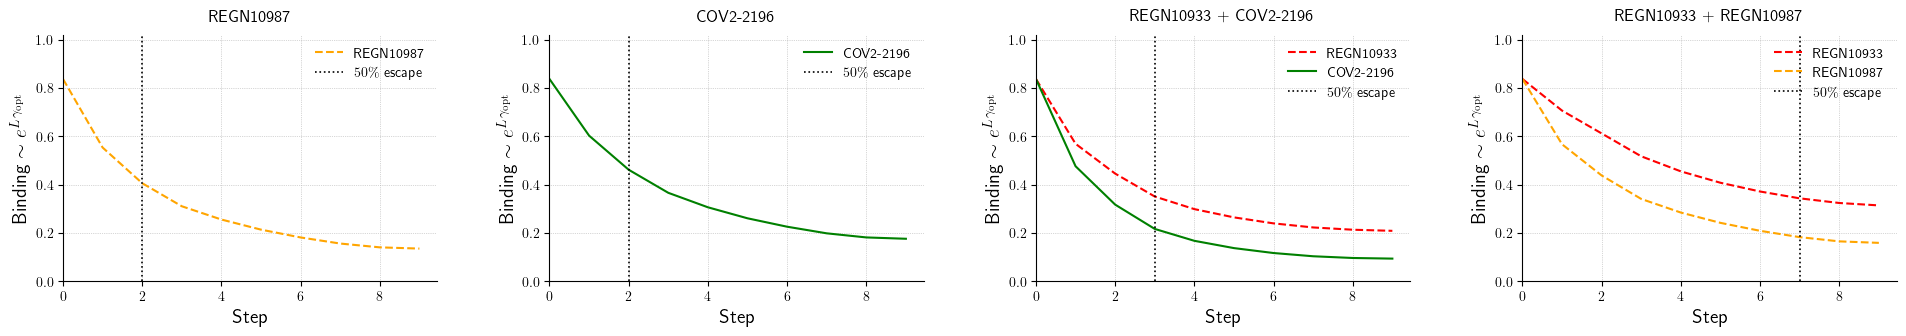

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Define antibody appearance
style_dict = {
    "REGN10933": {"color": "red", "linestyle": "--"},
    "REGN10987": {"color": "orange", "linestyle": "--"},
    "LY-CoV555": {"color": "deepskyblue", "linestyle": "-"},
    "LY-CoV016": {"color": "darkblue", "linestyle": "-"},
    "COV2-2196": {"color": "green", "linestyle": "-"},
}
indexes_abs = [ab_names.index(ab) for ab in ab_focused]
dir = 'results_scripts/cocktail/'

# Set condition sets
import os
import re

# Setup
dir = 'results_scripts/cocktail'
BETA_AB = 1

# Your extract_parameters function
def extract_parameters(path):
    beta_ab_match = re.search(r'beta_ab_(\d+(?:\.\d+)?)', path)
    D_match = re.search(r'D_(\d+)', path)
    ab_parts = path.split('ab_')
    condition = ab_parts[3] if len(ab_parts) > 3 else None
    return {
        "beta_ab": float(beta_ab_match.group(1)) if beta_ab_match else None,
        "D": int(D_match.group(1)) if D_match else None,
        "condition": condition
    }

# Define all condition sets
condition_sets = [
    ["REGN10987", "COV2-2196", "REGN10933_COV2-2196"],
    # ["LY-CoV016", "LY-CoV016_LY-CoV555", "LY-CoV555"],
     ["REGN10933_REGN10987"],

]

# Get all folders
all_dirs = [d for d in os.listdir(dir) if os.path.isdir(os.path.join(dir, d))]

# Initialize lists
paths = []
labels = []

# Loop through each condition set and each condition
for condition_set in condition_sets:
    for condition in condition_set:
        for d in all_dirs:
            params = extract_parameters(d)
            if (
                params["beta_ab"] == BETA_AB and
                params["D"] == D and
                params["condition"] == condition
            ):
                paths.append(d)
                labels.append(condition)
                break  # Use only the first matching folder

# Check: paths[i] corresponds to labels[i]
for p, l in zip(paths, labels):
    print(f"{l}: {p}")


import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
import os

# Use LaTeX-style text
mpl.rcParams.update({
    "text.usetex": True,
    # "font.family": "sans-serif",
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})

# Determine layout
n_paths = len(labels)
n_cols = 4
n_rows = math.ceil(n_paths / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, condition in enumerate(labels):
    abs_involved = condition.split("_") if "_" in condition else [condition]

    # Load data
    mopt = np.exp(np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :] * L)

    ax = axes[i]

    # Plot each antibody
    for ab in abs_involved:
        ab_idx = ab_names.index(ab)
        ax.plot(mopt[:, ab_idx],
                label=ab,
                color=style_dict[ab]["color"],
                linestyle=style_dict[ab]["linestyle"],
                linewidth=1.5)

    # Mark 50% escape threshold
    indices = [ab_names.index(ab) for ab in abs_involved]
    prod_escape = np.prod(1 - mopt[:, indices], axis=1)
    cross_idx = np.argmax(prod_escape > 0.5) if np.any(prod_escape > 0.5) else None
    if cross_idx is not None:
        ax.axvline(cross_idx, color="black", linestyle=":", linewidth=1.2, label=r"$50\%$ escape")

    # Format subplot
    ax.set_title(condition.replace("_", " + "), pad=10)
    ax.set_xlabel(r"Step", fontsize=14)
    ax.set_ylabel(r"Binding $\sim e^{L\, \gamma_{\mathrm{opt}}}$", fontsize=14)
    ax.set_ylim(0, 1.02)
    ax.set_xlim(left=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, which='major', linestyle=':', linewidth=0.5)
    ax.legend(frameon=False, loc='upper right')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.2)
plt.subplots_adjust(hspace=0.35, wspace=0.3)
plt.show()



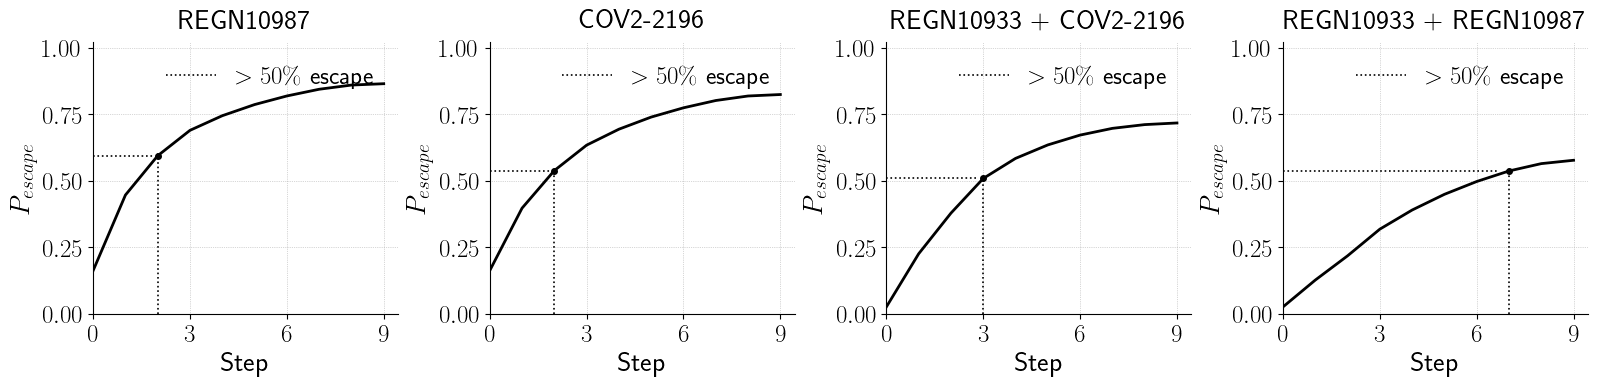

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
import os

# LaTeX formatting
mpl.rcParams.update({
    "text.usetex": True,
    "axes.titlesize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 18
})

# Layout
n_paths = len(labels)
n_cols = 4
n_rows = math.ceil(n_paths / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, condition in enumerate(labels):
    abs_involved = condition.split("_") if "_" in condition else [condition]

    # Load data
    mopt = np.exp(np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :] * L)

    ax = axes[i]

    # Compute antibody fitness: product over (1 - mopt_i)
    indices = [ab_names.index(ab) for ab in abs_involved]
    fitness = np.prod(1 - mopt[:, indices], axis=1)

    # Plot fitness curve
    ax.plot(fitness,
            color="black",
            linestyle="-",
            linewidth=2)

    # Mark 50% escape threshold
    # cross_idx = np.argmax(fitness > 0.5) if np.any(fitness > 0.5) else None
    # if cross_idx is not None:
    #     ax.axvline(cross_idx, color="black", linestyle=":", linewidth=1.2, label=r"$50\%$ escape")

    # Mark 50% escape threshold with crosshairs
    cross_idx = np.argmax(fitness > 0.5) if np.any(fitness > 0.5) else None
    if cross_idx is not None:
        fitness_val = fitness[cross_idx]
        ax.axvline(cross_idx, ymax=fitness_val, color="black", linestyle=":", linewidth=1.2)
        ax.axhline(fitness_val, xmax=cross_idx / len(fitness), color="black", linestyle=":", linewidth=1.2)
        ax.plot(cross_idx, fitness_val, marker='o', color='black', markersize=4)


    # Format subplot
    ax.set_title(condition.replace("_", " + "), pad=10)
    ax.set_xlabel(r"Step", fontsize=20)
    ax.set_ylabel(r"$P_{escape}$", fontsize=20)
    ax.set_ylim(0, 1.02)
    ax.set_xlim(left=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, which='major', linestyle=':', linewidth=0.5)
    ax.set_xticks(np.arange(0, len(fitness), 3))

    # Add dashed line to legend
    ax.plot([], [], color="black", linestyle=":", linewidth=1.2, label=r"$>50\%$ escape")

    ax.legend(frameon=False, loc='upper right')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.2)
plt.subplots_adjust(hspace=0.35, wspace=0.3)
plt.show()


# all cocktails with REGN 10933

In [11]:
import os
import numpy as np
all_dirs = [d for d in os.listdir(dir) if os.path.isdir(os.path.join(dir, d))]

# Initialize lists
all_paths = []
labels = []


for d in all_dirs:
    params = extract_parameters(d)
    if (
        params["beta_ab"] == BETA_AB and
        params["D"] == D 
    ):
        all_paths.append(d)
        labels.append(condition)


def get_escape_step(filepath, ab_indices, L):
    """Compute escape step where fitness crosses 0.5"""
    mopt = np.exp(np.load(filepath+'/mopt.npy')[:, :] * L)
    fitness = np.prod(1 - mopt[:, ab_indices], axis=1)
    escape_step = np.argmax(fitness > 0.5) if np.any(fitness > 0.5) else len(fitness)
    return escape_step

def compute_delta_escape_steps(all_dir, ab_names, L):
    results = {}

    for fname in os.listdir(all_dir):
        if not fname.startswith("mean_f_free_ab_beta_ab_1_D_10_ab_"):
            continue
     

        ab_part = fname.split("ab_")[3]
        abs_involved = ab_part.split("_")
        abs_involved = [ab for ab in abs_involved if ab in ab_names]

        if len(abs_involved) < 2:
            continue  # skip single-Ab files

        cocktail_path = os.path.join(dir, fname)
        cocktail_indices = [ab_names.index(ab) for ab in abs_involved]
        cocktail_escape = get_escape_step(cocktail_path, cocktail_indices, L)

        single_escapes = []
        for ab in abs_involved:
            ab_fname = f"mean_f_free_ab_beta_ab_1_D_10_ab_{ab}"
            ab_path = os.path.join(all_dir, ab_fname)
            if not os.path.exists(ab_path):
                print(f"Missing file for {ab}, skipping cocktail {fname}")
                break
            ab_index = [ab_names.index(ab)]
            ab_escape = get_escape_step(ab_path, ab_index, L)
            single_escapes.append(ab_escape)
        else:
            # Only compute delta if all files found
            delta = cocktail_escape - max(single_escapes)
            results[fname] = {
                "cocktail_step": cocktail_escape,
                "individual_steps": dict(zip(abs_involved, single_escapes)),
                "delta_escape_step": delta
            }

    return results
delta_steps = compute_delta_escape_steps(dir, ab_names, L)
delta_steps

{'mean_f_free_ab_beta_ab_1_D_10_ab_REGN10933_COV2-2050': {'cocktail_step': 10,
  'individual_steps': {'REGN10933': 3, 'COV2-2050': 10},
  'delta_escape_step': 0},
 'mean_f_free_ab_beta_ab_1_D_10_ab_REGN10933_COV2-2082': {'cocktail_step': 10,
  'individual_steps': {'REGN10933': 3, 'COV2-2082': 10},
  'delta_escape_step': 0},
 'mean_f_free_ab_beta_ab_1_D_10_ab_REGN10933_COV2-2094': {'cocktail_step': 10,
  'individual_steps': {'REGN10933': 3, 'COV2-2094': 10},
  'delta_escape_step': 0},
 'mean_f_free_ab_beta_ab_1_D_10_ab_REGN10933_COV2-2096': {'cocktail_step': 10,
  'individual_steps': {'REGN10933': 3, 'COV2-2096': 10},
  'delta_escape_step': 0},
 'mean_f_free_ab_beta_ab_1_D_10_ab_REGN10933_COV2-2130': {'cocktail_step': 10,
  'individual_steps': {'REGN10933': 3, 'COV2-2130': 5},
  'delta_escape_step': 5},
 'mean_f_free_ab_beta_ab_1_D_10_ab_REGN10933_COV2-2165': {'cocktail_step': 10,
  'individual_steps': {'REGN10933': 3, 'COV2-2165': 10},
  'delta_escape_step': 0},
 'mean_f_free_ab_beta_a

## Delta escape cocktail vs single ab, compared to corr wighted by MSA

In [12]:
msa_seqs=Proteins_utils.load_FASTA('../covid/esmif_seq/sampled_sequences_temp_1.fasta')
msa_seqs.shape

(1000, 178)

In [13]:
escapes = np.array([get_log_bindings(msa_seqs[i]) for i in range(msa_seqs.shape[0])])
escapes.shape  #1000*29 as wqe have 29 abs


(1000, 29)

C:\Users\maria\AppData\Local\Temp\ipykernel_15824\3391741169.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


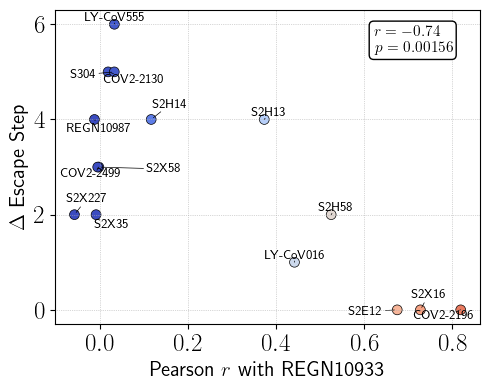

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from adjustText import adjust_text
from matplotlib import cm
def pearson_corr(x, y):
    x_centered = x - x.mean()
    y_centered = y - y.mean()
    return np.dot(x_centered, y_centered) / (np.linalg.norm(x_centered) * np.linalg.norm(y_centered))

target_ab = 'REGN10933'
target_idx = ab_names.index(target_ab)
# Data containers
corrs = []
deltas = []
other_abs = []

# Loop through cocktails
for cocktail_name, vals in delta_steps.items():
    abs_involved = [ab for ab in vals['individual_steps'] if ab != target_ab]
    if len(abs_involved) != 1:
        continue  # Only REGN10933 + 1

    other_ab = abs_involved[0]
    indiv_steps = vals['individual_steps']

    if indiv_steps.get(target_ab, 0) >= 10 or indiv_steps.get(other_ab, 0) >= 10:
        continue

    other_idx = ab_names.index(other_ab)

    x = escapes[:, target_idx]
    y = escapes[:, other_idx]

    corr = pearson_corr(x, y)
    corrs.append(corr)
    deltas.append(vals['delta_escape_step'])
    other_abs.append(other_ab)

# Compute global Pearson r and p-value
r, pval = pearsonr(corrs, deltas)

# === Plot ===
fig, ax = plt.subplots(figsize=(5, 4))

# Define a colormap: use 'coolwarm' or 'plasma' or 'viridis' depending on style preference
cmap = cm.get_cmap('coolwarm')

# Normalize corrs to [0, 1] for color mapping
norm_corrs = (np.array(corrs) - 0) / (1 - 0)  # assuming corrs between 0 and 1
colors = cmap(norm_corrs)

# Scatter plot with colors
ax.scatter(corrs, deltas, color=colors, s=50, edgecolor='black', linewidth=0.5)

# Label points using adjust_text
texts = [ax.text(corrs[i], deltas[i], label, fontsize=9, ha='center') for i, label in enumerate(other_abs)]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.5), force_text=(0.6, 0.9))

# Axis labels and title
ax.set_xlabel("Pearson $r$ with REGN10933", fontsize=15)
ax.set_ylabel(r"$\Delta$ Escape Step", fontsize=15)
ax.grid(True, linestyle=':', linewidth=0.5)

# Add Pearson stats in a box
stat_text = fr"$r = {r:.2f}$" + "\n" + fr"$p = {pval:.3g}$"
ax.text(0.75, 0.95, stat_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.show()


# Scaling of nb of antibodies

In [15]:
import os

PREFIX = "mean_f_free_ab_beta_ab_1_D_10_ab_"

def compute_incremental_escape_steps(base_dir: str, ab_order: list[str], ab_names: list[str], L: int):
    """
    For k = 1..len(ab_order), compute the escape step for the cocktail consisting of the first k antibodies.
    Expects folders named like: mean_f_free_ab_beta_ab_1_D_10_ab_<AB1>_<AB2>_..._<ABk>
    """
    results = []
    prev_step = None

    for k in range(1, len(ab_order) + 1):
        combo = ab_order[:k]
        folder = PREFIX + "_".join(combo)
        path = os.path.join(base_dir, folder)

        if not os.path.exists(path):
            print(f"[warn] Missing folder for cocktail {k}: {folder}")
            continue

        # map antibodies in this combo to column indices in mopt
        try:
            indices = [ab_names.index(ab) for ab in combo]
        except ValueError as e:
            missing = [ab for ab in combo if ab not in ab_names]
            raise ValueError(f"Antibodies not found in ab_names: {missing}") from e

        step = get_escape_step(path, indices, L)
        delta_vs_prev = None if prev_step is None else step - prev_step
        results.append({
            "k": k,
            "abs": combo,
            "folder": folder,
            "escape_step": step,
            "delta_vs_prev": delta_vs_prev,
        })
        prev_step = step

    return results

# Example usage with your order:
ab_order = ["REGN10933", "COV2-2196", "S2X16", "S2E12", "S2H58", "LY-CoV016", "S2H13"]
incremental = compute_incremental_escape_steps(dir, ab_order, ab_names, L)
for r in incremental:
    print(f"{r['k']}: {_:=<2} {' + '.join(r['abs'])} -> step {r['escape_step']}"
          + ("" if r['delta_vs_prev'] is None else f" (Δ vs prev: {r['delta_vs_prev']})"))


1: ok REGN10933 -> step 3
2: ok REGN10933 + COV2-2196 -> step 3 (Δ vs prev: 0)
3: ok REGN10933 + COV2-2196 + S2X16 -> step 3 (Δ vs prev: 0)
4: ok REGN10933 + COV2-2196 + S2X16 + S2E12 -> step 3 (Δ vs prev: 0)
5: ok REGN10933 + COV2-2196 + S2X16 + S2E12 + S2H58 -> step 7 (Δ vs prev: 4)
6: ok REGN10933 + COV2-2196 + S2X16 + S2E12 + S2H58 + LY-CoV016 -> step 7 (Δ vs prev: 0)
7: ok REGN10933 + COV2-2196 + S2X16 + S2E12 + S2H58 + LY-CoV016 + S2H13 -> step 8 (Δ vs prev: 1)


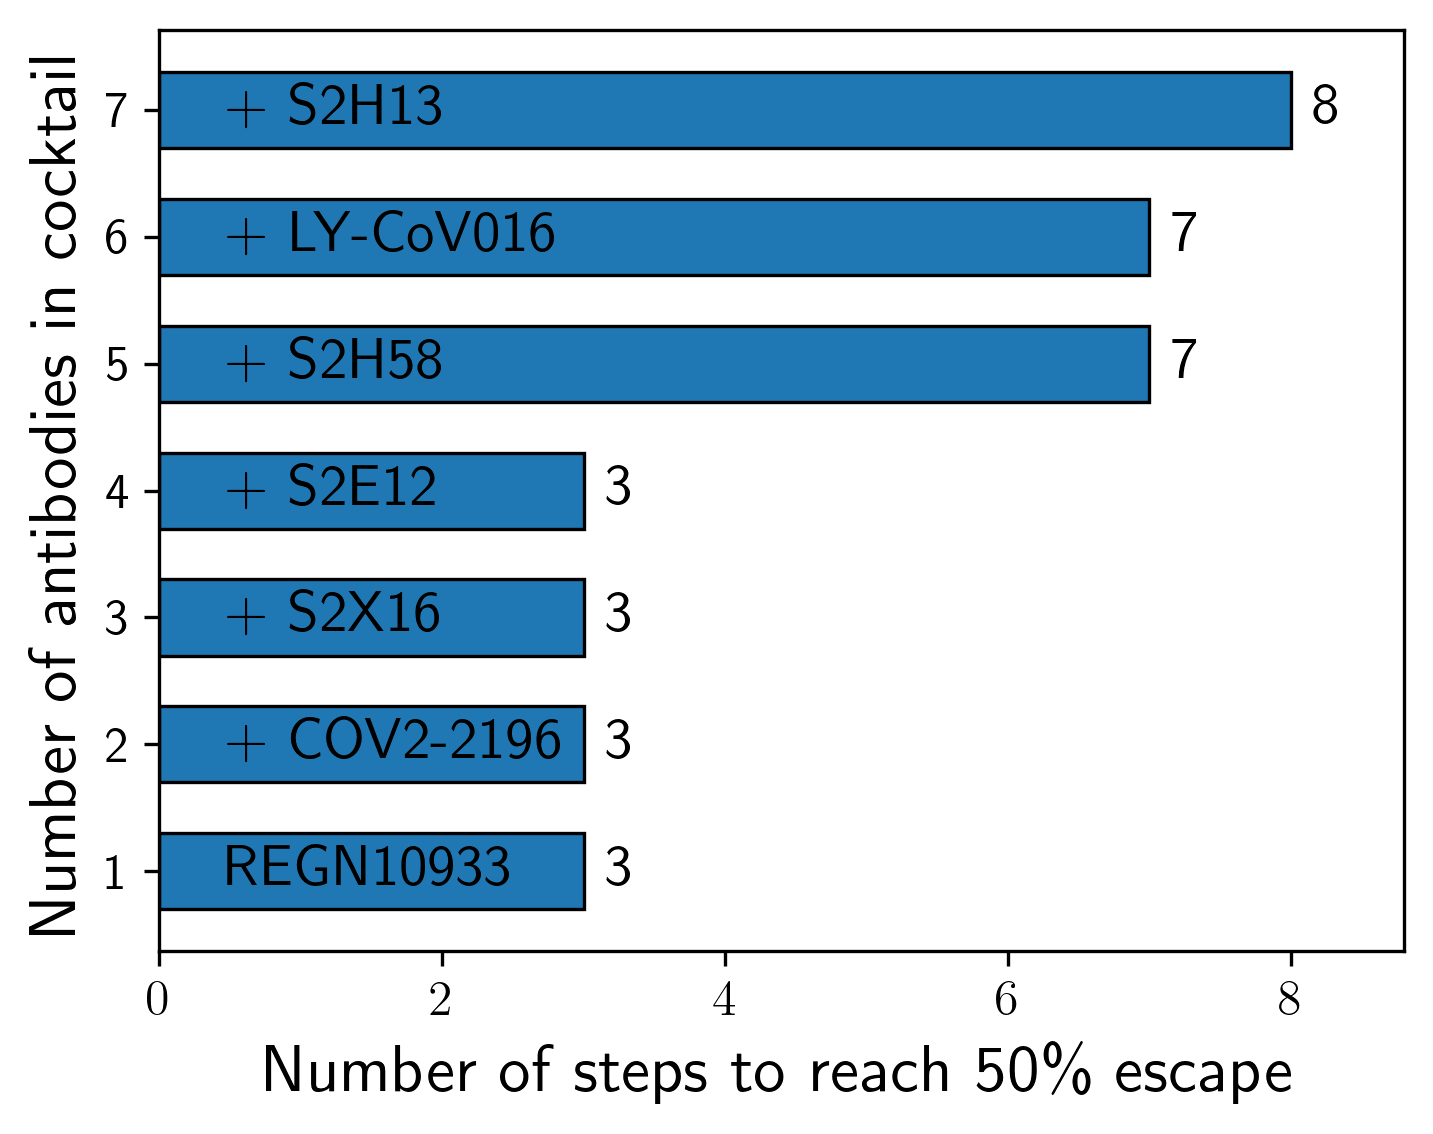

In [39]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

def _nature_style():
    # mpl.rcParams.update({
    #     # fonts & sizes
    #     "font.family": "DejaVu Sans",
    #     "font.size": 9,
    #     "axes.titlesize": 10,
    #     "axes.labelsize": 9,
    #     "xtick.labelsize": 8,
    #     "ytick.labelsize": 8,
    #     "legend.fontsize": 8,
    #     # lines & ticks
    #     "axes.linewidth": 0.8,
    #     "xtick.direction": "out",
    #     "ytick.direction": "out",
    #     "xtick.major.width": 0.8,
    #     "ytick.major.width": 0.8,
    #     "xtick.minor.visible": False,
    #     "ytick.minor.visible": False,
    #     # layout
    #     "figure.dpi": 300,
    # })

        mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": "Arial",
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "lines.markersize": 6,
        "lines.linewidth": 2,
        "figure.dpi": 300
    })

def plot_additional_escape_steps(incremental, savepath=None, title=None):
    """
    incremental: list of dicts from compute_incremental_escape_steps(...)
                 Each has keys: 'k', 'abs', 'escape_step', ...
    Plots Δ escape steps relative to k=1 (REGN10933 alone) for k >= 2.
    """
    if not incremental:
        raise ValueError("Empty 'incremental' data.")

    # Sort by k to be safe
    data = sorted(incremental, key=lambda r: r["k"])
    # Baseline: REGN10933 alone should be k=1
    base = next((r for r in data if r["k"] == 1), None)
    if base is None:
        raise ValueError("No k=1 baseline (REGN10933 alone) found in 'incremental'.")

    base_step = base["escape_step"]

    # Build arrays: include k=1 and plot absolute required steps
    records = [r for r in data if r["k"] >= 2]
    if not records:
        raise ValueError("No k>=2 entries found — nothing to plot.")
    k_vals = [r["k"] for r in data]                          # include baseline
    steps  = [max(0, r["escape_step"]) for r in data]        # absolute steps
    # Antibody added at this stage: last element in the combo (for k>=2 only)
    plus_abs = [r["abs"][-1] if r["abs"] else "?" for r in records]

    # Styling
    _nature_style()

    fig_w, fig_h = 5, 4  # inches; compact “Nature figure” footprint
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # Y positions now for all k (including k=1)
    y_pos = np.arange(len(k_vals))

    # Bars: horizontal, with thin edge for print clarity
    ax.barh(
        y=y_pos,
        width=steps,
        height=0.6,
        edgecolor="black",
        linewidth=0.8
    )

    # Axis labels
    ax.set_xlabel("Number of steps to reach 50\\% escape")
    ax.set_ylabel("Number of antibodies in cocktail")

    # Y ticks labeled by k (1, 2, …)
    ax.set_yticks(y_pos, labels=[str(k) for k in k_vals])

    # Nice x limits & margin
    max_x = max(steps) if steps else 1.0
    ax.set_xlim(0, max_x * 1.1 if max_x > 0 else 1.0)

    # Frame/spines thin (already in rcParams), keep all spines visible
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    # No grid (clean journal style)
    ax.grid(False)

    # Optional title (Nature often omits; keep subtle if used)
    if title:
        ax.set_title(title, pad=6)

    # Antibody annotations near the y-axis to show which ab was added
    # Align them with k>=2 bars only (skip baseline y=0)
    x_text = max_x * 0.06 if max_x > 0 else 0.06  # small offset
    x_tip = max_x * 0.003 if max_x > 0 else 0.003

    for y, ab in zip(y_pos[1:], plus_abs):
        ax.annotate(
            f"+ {ab}",
            xy=(x_tip, y), xycoords="data",
            xytext=(x_text, y), textcoords="data",
            va="center", ha="left",
            clip_on=False
        )

    ax.annotate(
            "REGN10933",
            xy=(x_tip, y_pos[0]), xycoords="data",
            xytext=(x_text, y_pos[0]), textcoords="data",
            va="center", ha="left",
            clip_on=False
        )

    # Numeric labels at end of each bar (optional but handy)
    for y, val in zip(y_pos, steps):
        ax.text(val + max_x * 0.02, y, f"{val}", va="center", ha="left")

    fig.tight_layout()


    return fig, ax

# --- Example usage ---
incremental = compute_incremental_escape_steps(dir, ab_order, ab_names, L)
plot_additional_escape_steps(incremental)
plt.show()
